<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

<a name="inicio3"></a>


# **3. Diseño de Experimentos 2026 con R y Python - P3**

## **https://rpubs.com/jseferino/DOEP3**

## **24.** [ EJEMPLO 1: PRUEBA PARA LA MEDIA](#T24)

## **25.** [EJEMPLO 2: PRUEBA PARA UNA PROPORCIÓN](#T25)

## **26.** [EJEMPLO 3: PRUEBA t PARA UNA MEDIA](#T26)

## **27.** [EJEMPLO 4: PRUEBA t PARA DIFERENCIA DE MEDIAS](#T27)


## **28.** [EJEMPLO 5: PRUEBA CHI-CUADRADO PARA UNA VARIANZA](#T28)


[⬆️ Volver al inicio](#inicio3)

<a name="T24"></a>
## **24.  EJEMPLO 1: PRUEBA PARA LA MEDIA**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== PRUEBA DE HIPÓTESIS PARA LA MEDIA ===
H₀: μ = 15 vs H₁: μ > 15
Estadístico Z: 4 
Valor crítico (α=0.05): 1.6449 
Valor-p: 3.2e-05 

Decisión: Rechazar H₀
Conclusión: El número promedio de prospectos excede a 15.


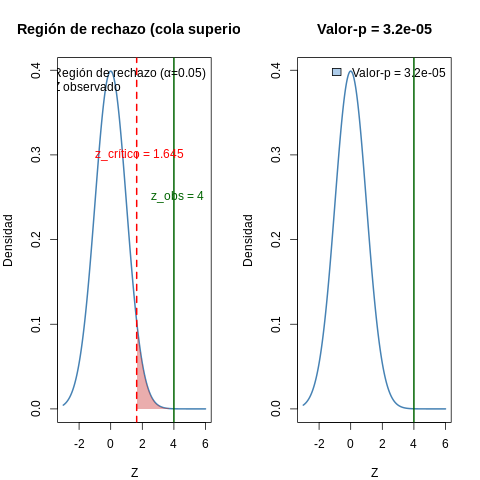

In [ ]:

# ============================================
# @title **B.  EJEMPLO 1: PRUEBA PARA LA MEDIA (VENTAS)**
# ============================================
%%R
# Datos
n <- 36
y_bar <- 17
s <- 3
mu0 <- 15
alpha <- 0.05

# Estadístico de prueba
z <- (y_bar - mu0) / (s / sqrt(n))
z_critico <- qnorm(1 - alpha)
p_valor <- 1 - pnorm(z)

cat("=== PRUEBA DE HIPÓTESIS PARA LA MEDIA ===\n")
cat("H₀: μ = 15 vs H₁: μ > 15\n")
cat("Estadístico Z:", round(z, 4), "\n")
cat("Valor crítico (α=0.05):", round(z_critico, 4), "\n")
cat("Valor-p:", round(p_valor, 6), "\n\n")

if (z > z_critico) {
  cat("Decisión: Rechazar H₀\n")
  cat("Conclusión: El número promedio de prospectos excede a 15.\n")
} else {
  cat("Decisión: No rechazar H₀\n")
  cat("Conclusión: No hay evidencia suficiente para afirmar que el promedio excede a 15.\n")
}

# ============================================
# VISUALIZACIÓN
# ============================================

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución normal con región de rechazo
x_vals <- seq(-3, 6, length.out = 500)
densidad <- dnorm(x_vals)

plot(x_vals, densidad, type = "l", lwd = 2, col = "steelblue",
     xlab = "Z", ylab = "Densidad",
     main = "Región de rechazo (cola superior)")

# Región de rechazo
x_rechazo <- seq(z_critico, 6, length.out = 100)
y_rechazo <- dnorm(x_rechazo)
polygon(c(x_rechazo, rev(x_rechazo)), c(y_rechazo, rep(0, length(x_rechazo))),
        col = rgb(0.8, 0.2, 0.2, 0.4), border = NA)

abline(v = z_critico, col = "red", lty = 2, lwd = 2)
abline(v = z, col = "darkgreen", lwd = 2)
text(z_critico + 0.2, 0.3, labels = paste("z_crítico =", round(z_critico, 3)), col = "red")
text(z + 0.2, 0.25, labels = paste("z_obs =", round(z, 3)), col = "darkgreen")

legend("topright",
       legend = c("Región de rechazo (α=0.05)", "Z observado"),
       fill = c(rgb(0.8, 0.2, 0.2, 0.4), NA),
       col = c(NA, "darkgreen"), lty = c(NA, 1), lwd = c(NA, 2), bty = "n")

# Gráfico 2: Valor-p
plot(x_vals, densidad, type = "l", lwd = 2, col = "steelblue",
     xlab = "Z", ylab = "Densidad",
     main = paste("Valor-p =", round(p_valor, 6)))

x_pvalor <- seq(z, 6, length.out = 100)
y_pvalor <- dnorm(x_pvalor)
polygon(c(x_pvalor, rev(x_pvalor)), c(y_pvalor, rep(0, length(x_pvalor))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)
abline(v = z, col = "darkgreen", lwd = 2)

legend("topright",
       legend = paste("Valor-p =", round(p_valor, 6)),
       fill = rgb(0.2, 0.5, 0.8, 0.4), bty = "n")


=== PRUEBA DE HIPÓTESIS PARA LA MEDIA ===
H₀: μ = 15 vs H₁: μ > 15
Estadístico Z: 4.0000
Valor crítico (α=0.05): 1.6449
Valor-p: 0.000032

Decisión: Rechazar H₀
Conclusión: El número promedio de prospectos excede a 15.


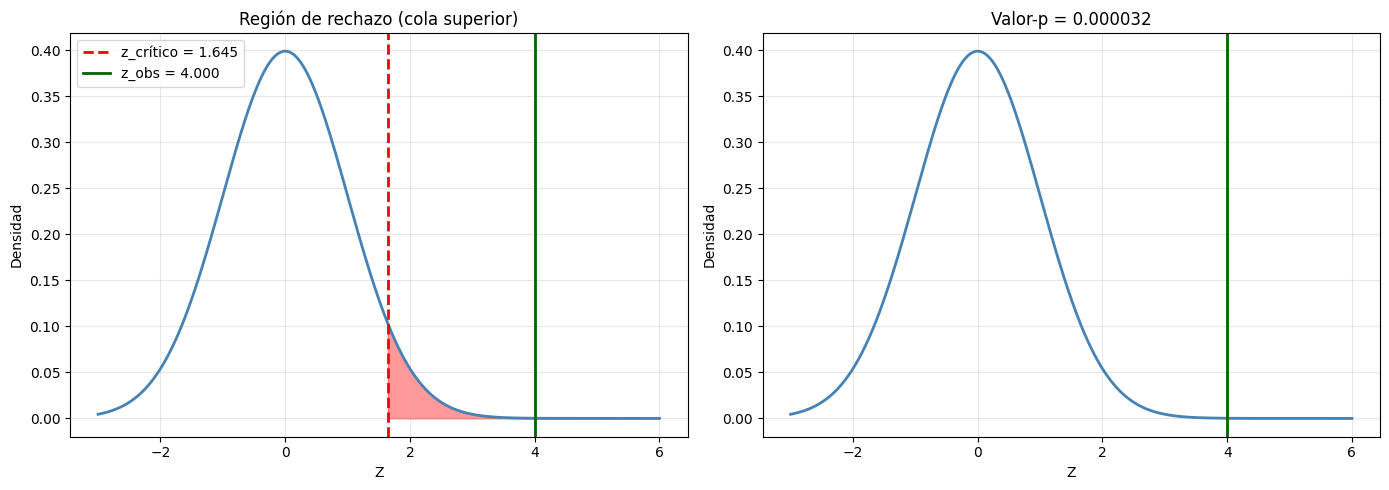

In [ ]:

# ============================================
# @title **C.  EJEMPLO 1: PRUEBA PARA LA MEDIA (VENTAS)**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos
n = 36
y_bar = 17
s = 3
mu0 = 15
alpha = 0.05

# Estadístico de prueba
z = (y_bar - mu0) / (s / np.sqrt(n))
z_critico = norm.ppf(1 - alpha)
p_valor = 1 - norm.cdf(z)

print("=== PRUEBA DE HIPÓTESIS PARA LA MEDIA ===")
print(f"H₀: μ = 15 vs H₁: μ > 15")
print(f"Estadístico Z: {z:.4f}")
print(f"Valor crítico (α=0.05): {z_critico:.4f}")
print(f"Valor-p: {p_valor:.6f}\n")

if z > z_critico:
    print("Decisión: Rechazar H₀")
    print("Conclusión: El número promedio de prospectos excede a 15.")
else:
    print("Decisión: No rechazar H₀")
    print("Conclusión: No hay evidencia suficiente para afirmar que el promedio excede a 15.")

# ============================================
# VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución normal con región de rechazo
x_vals = np.linspace(-3, 6, 500)
densidad = norm.pdf(x_vals)

axes[0].plot(x_vals, densidad, 'steelblue', lw=2)

# Región de rechazo
x_rechazo = np.linspace(z_critico, 6, 100)
y_rechazo = norm.pdf(x_rechazo)
axes[0].fill_between(x_rechazo, y_rechazo, alpha=0.4, color='red')
axes[0].axvline(z_critico, color='red', linestyle='--', lw=2,
                label=f'z_crítico = {z_critico:.3f}')
axes[0].axvline(z, color='darkgreen', lw=2, label=f'z_obs = {z:.3f}')
axes[0].set_xlabel('Z')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Región de rechazo (cola superior)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Valor-p
axes[1].plot(x_vals, densidad, 'steelblue', lw=2)

x_pvalor = np.linspace(z, 6, 100)
y_pvalor = norm.pdf(x_pvalor)
axes[1].fill_between(x_pvalor, y_pvalor, alpha=0.4, color='steelblue')
axes[1].axvline(z, color='darkgreen', lw=2)
axes[1].set_xlabel('Z')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Valor-p = {p_valor:.6f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




[⬆️ Volver al inicio](#inicio3)

<a name="T25"></a>
## **25. EJEMPLO 2: PRUEBA PARA UNA PROPORCIÓN**




In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== PRUEBA DE HIPÓTESIS PARA UNA PROPORCIÓN ===
H₀: p = 0.10 vs H₁: p > 0.10
Proporción muestral: 0.15 
Estadístico Z: 1.6667 
Valor crítico (α=0.01): 2.3263 
Valor-p: 0.0478 

Decisión: No rechazar H₀
Conclusión: No hay suficiente evidencia para afirmar que la proporción excede el 10%.


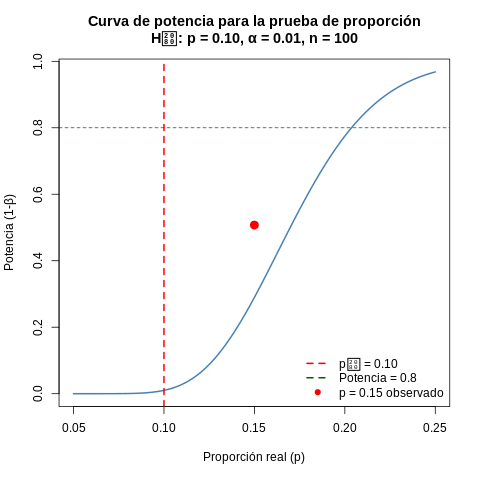

In [ ]:

# ============================================
# @title **B. EJEMPLO 2: PRUEBA PARA UNA PROPORCIÓN**
# ============================================
%%R
# Datos
n <- 100
x <- 15
p_hat <- x / n
p0 <- 0.10
alpha <- 0.01

# Estadístico de prueba
z <- (p_hat - p0) / sqrt(p0 * (1 - p0) / n)
z_critico <- qnorm(1 - alpha)
p_valor <- 1 - pnorm(z)

cat("=== PRUEBA DE HIPÓTESIS PARA UNA PROPORCIÓN ===\n")
cat("H₀: p = 0.10 vs H₁: p > 0.10\n")
cat("Proporción muestral:", round(p_hat, 4), "\n")
cat("Estadístico Z:", round(z, 4), "\n")
cat("Valor crítico (α=0.01):", round(z_critico, 4), "\n")
cat("Valor-p:", round(p_valor, 4), "\n\n")

if (z > z_critico) {
  cat("Decisión: Rechazar H₀\n")
  cat("Conclusión: La proporción de defectuosos excede el 10%.\n")
} else {
  cat("Decisión: No rechazar H₀\n")
  cat("Conclusión: No hay suficiente evidencia para afirmar que la proporción excede el 10%.\n")
}

# ============================================
# CURVA DE POTENCIA
# ============================================

# Función para calcular la potencia
p_values <- seq(0.05, 0.25, length.out = 100)
potencia <- 1 - pnorm((p0 - p_values + z_critico * sqrt(p0*(1-p0)/n)) / sqrt(p_values*(1-p_values)/n))

plot(p_values, potencia, type = "l", lwd = 2, col = "steelblue",
     xlab = "Proporción real (p)", ylab = "Potencia (1-β)",
     main = "Curva de potencia para la prueba de proporción\nH₀: p = 0.10, α = 0.01, n = 100")
abline(v = p0, col = "red", lty = 2, lwd = 2)
abline(h = 0.8, col = "darkgreen", lty = 2)
points(0.15, 1 - pnorm((0.10 - 0.15 + 1.645*sqrt(0.10*0.90/100)) / sqrt(0.15*0.85/100)),
       col = "red", pch = 19, cex = 1.5)
legend("bottomright",
       legend = c("p₀ = 0.10", "Potencia = 0.8", "p = 0.15 observado"),
       col = c("red", "darkgreen", "red"), lty = c(2, 2, NA),
       pch = c(NA, NA, 19), lwd = c(2, 2, NA), bty = "n")




=== PRUEBA DE HIPÓTESIS PARA UNA PROPORCIÓN ===
H₀: p = 0.10 vs H₁: p > 0.10
Proporción muestral: 0.1500
Estadístico Z: 1.6667
Valor crítico (α=0.01): 2.3263
Valor-p: 0.0478

Decisión: No rechazar H₀
Conclusión: No hay suficiente evidencia para afirmar que la proporción excede el 10%.


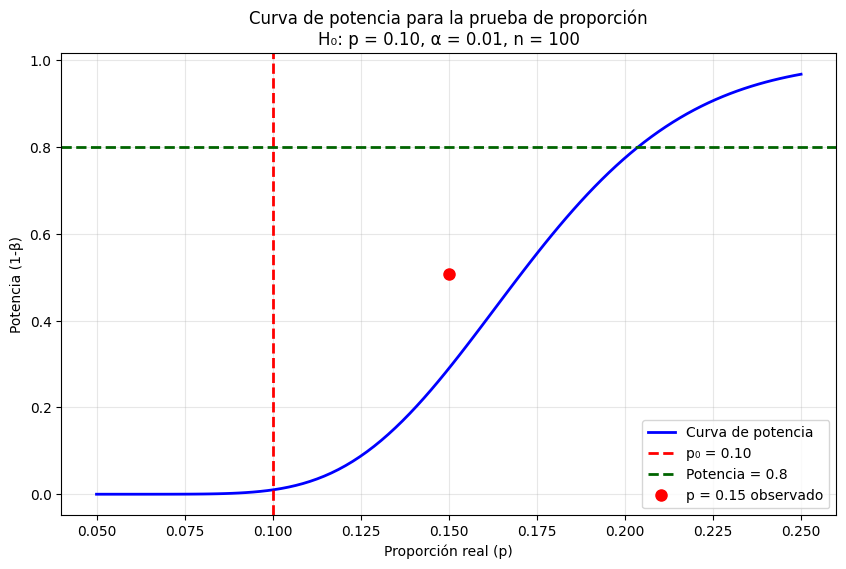

In [ ]:
# ============================================
# @title **C. EJEMPLO 2: PRUEBA PARA UNA PROPORCIÓN**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos
n = 100
x = 15
p_hat = x / n
p0 = 0.10
alpha = 0.01

# Estadístico de prueba
z = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n)
z_critico = norm.ppf(1 - alpha)
p_valor = 1 - norm.cdf(z)

print("=== PRUEBA DE HIPÓTESIS PARA UNA PROPORCIÓN ===")
print(f"H₀: p = 0.10 vs H₁: p > 0.10")
print(f"Proporción muestral: {p_hat:.4f}")
print(f"Estadístico Z: {z:.4f}")
print(f"Valor crítico (α=0.01): {z_critico:.4f}")
print(f"Valor-p: {p_valor:.4f}\n")

if z > z_critico:
    print("Decisión: Rechazar H₀")
    print("Conclusión: La proporción de defectuosos excede el 10%.")
else:
    print("Decisión: No rechazar H₀")
    print("Conclusión: No hay suficiente evidencia para afirmar que la proporción excede el 10%.")

# ============================================
# CURVA DE POTENCIA
# ============================================

p_values = np.linspace(0.05, 0.25, 100)
potencia = 1 - norm.cdf((p0 - p_values + z_critico * np.sqrt(p0*(1-p0)/n)) /
                         np.sqrt(p_values*(1-p_values)/n))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_values, potencia, 'b-', lw=2, label='Curva de potencia')
ax.axvline(p0, color='red', linestyle='--', lw=2, label='p₀ = 0.10')
ax.axhline(0.8, color='darkgreen', linestyle='--', lw=2, label='Potencia = 0.8')
ax.plot(0.15, 1 - norm.cdf((0.10 - 0.15 + 1.645*np.sqrt(0.10*0.90/100)) /
                            np.sqrt(0.15*0.85/100)),
        'ro', markersize=8, label='p = 0.15 observado')
ax.set_xlabel('Proporción real (p)')
ax.set_ylabel('Potencia (1-β)')
ax.set_title('Curva de potencia para la prueba de proporción\nH₀: p = 0.10, α = 0.01, n = 100')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio3)

<a name="T26"></a>
## **26. EJEMPLO 3: PRUEBA t PARA UNA MEDIA**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== PRUEBA t PARA UNA MEDIA ===
H₀: μ = 46 vs H₁: μ < 46
Estadístico t: -1.1644 
Valor crítico (α=0.05, cola inferior): -1.7959 
Valor-p: 0.1344 

Decisión: No rechazar H₀
Conclusión: No hay evidencia suficiente para afirmar que el consumo es menor que 46 kWh.


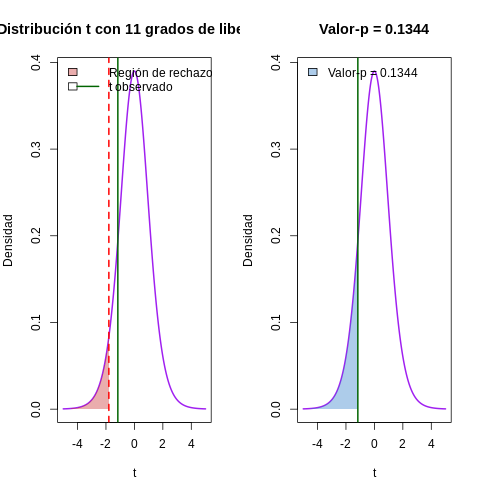

In [ ]:

# ============================================
# @title **B. EJEMPLO 3: PRUEBA t PARA UNA MEDIA**
# ============================================
%%R
# Datos
n <- 12
y_bar <- 42
s <- 11.9
mu0 <- 46
alpha <- 0.05

# Estadístico de prueba
t <- (y_bar - mu0) / (s / sqrt(n))
t_critico <- qt(alpha, df = n - 1)  # Cola inferior
p_valor <- pt(t, df = n - 1)

cat("=== PRUEBA t PARA UNA MEDIA ===\n")
cat("H₀: μ = 46 vs H₁: μ < 46\n")
cat("Estadístico t:", round(t, 4), "\n")
cat("Valor crítico (α=0.05, cola inferior):", round(t_critico, 4), "\n")
cat("Valor-p:", round(p_valor, 4), "\n\n")

if (t < t_critico) {
  cat("Decisión: Rechazar H₀\n")
  cat("Conclusión: El consumo promedio es menor que 46 kWh.\n")
} else {
  cat("Decisión: No rechazar H₀\n")
  cat("Conclusión: No hay evidencia suficiente para afirmar que el consumo es menor que 46 kWh.\n")
}

# ============================================
# VISUALIZACIÓN
# ============================================

x_vals <- seq(-5, 5, length.out = 500)
densidad_t <- dt(x_vals, df = n - 1)
densidad_norm <- dnorm(x_vals)

par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: Distribución t con región de rechazo
plot(x_vals, densidad_t, type = "l", lwd = 2, col = "purple",
     xlab = "t", ylab = "Densidad",
     main = paste("Distribución t con", n-1, "grados de libertad"))

# Región de rechazo (cola inferior)
x_rechazo <- seq(-5, t_critico, length.out = 100)
y_rechazo <- dt(x_rechazo, df = n - 1)
polygon(c(x_rechazo, rev(x_rechazo)), c(y_rechazo, rep(0, length(x_rechazo))),
        col = rgb(0.8, 0.2, 0.2, 0.4), border = NA)

abline(v = t_critico, col = "red", lty = 2, lwd = 2)
abline(v = t, col = "darkgreen", lwd = 2)

legend("topleft",
       legend = c("Región de rechazo (α=0.05)", "t observado"),
       fill = c(rgb(0.8, 0.2, 0.2, 0.4), NA),
       col = c(NA, "darkgreen"), lty = c(NA, 1), lwd = c(NA, 2), bty = "n")

# Gráfico 2: Valor-p
plot(x_vals, densidad_t, type = "l", lwd = 2, col = "purple",
     xlab = "t", ylab = "Densidad",
     main = paste("Valor-p =", round(p_valor, 4)))

x_pvalor <- seq(-5, t, length.out = 100)
y_pvalor <- dt(x_pvalor, df = n - 1)
polygon(c(x_pvalor, rev(x_pvalor)), c(y_pvalor, rep(0, length(x_pvalor))),
        col = rgb(0.2, 0.5, 0.8, 0.4), border = NA)
abline(v = t, col = "darkgreen", lwd = 2)

legend("topleft",
       legend = paste("Valor-p =", round(p_valor, 4)),
       fill = rgb(0.2, 0.5, 0.8, 0.4), bty = "n")





=== PRUEBA t PARA UNA MEDIA ===
H₀: μ = 46 vs H₁: μ < 46
Estadístico t: -1.1644
Valor crítico (α=0.05, cola inferior): -1.7959
Valor-p: 0.1344

Decisión: No rechazar H₀
Conclusión: No hay evidencia suficiente para afirmar que el consumo es menor que 46 kWh.


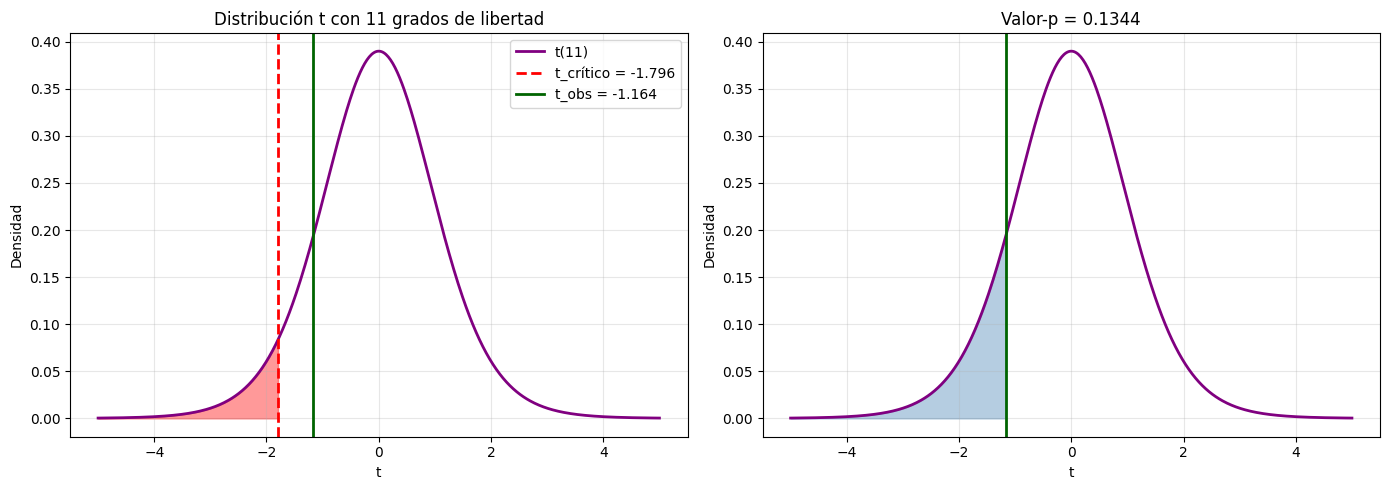

In [ ]:
# ============================================
# @title **C.  EJEMPLO 3: PRUEBA t PARA UNA MEDIA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Datos
n = 12
y_bar = 42
s = 11.9
mu0 = 46
alpha = 0.05

# Estadístico de prueba
t_stat = (y_bar - mu0) / (s / np.sqrt(n))
t_critico = t.ppf(alpha, df=n-1)  # Cola inferior
p_valor = t.cdf(t_stat, df=n-1)

print("=== PRUEBA t PARA UNA MEDIA ===")
print(f"H₀: μ = 46 vs H₁: μ < 46")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor crítico (α=0.05, cola inferior): {t_critico:.4f}")
print(f"Valor-p: {p_valor:.4f}\n")

if t_stat < t_critico:
    print("Decisión: Rechazar H₀")
    print("Conclusión: El consumo promedio es menor que 46 kWh.")
else:
    print("Decisión: No rechazar H₀")
    print("Conclusión: No hay evidencia suficiente para afirmar que el consumo es menor que 46 kWh.")

# ============================================
# VISUALIZACIÓN
# ============================================

x_vals = np.linspace(-5, 5, 500)
densidad_t = t.pdf(x_vals, df=n-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución t con región de rechazo
axes[0].plot(x_vals, densidad_t, 'purple', lw=2, label=f't({n-1})')

x_rechazo = np.linspace(-5, t_critico, 100)
y_rechazo = t.pdf(x_rechazo, df=n-1)
axes[0].fill_between(x_rechazo, y_rechazo, alpha=0.4, color='red')
axes[0].axvline(t_critico, color='red', linestyle='--', lw=2,
                label=f't_crítico = {t_critico:.3f}')
axes[0].axvline(t_stat, color='darkgreen', lw=2, label=f't_obs = {t_stat:.3f}')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución t con {n-1} grados de libertad')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Valor-p
axes[1].plot(x_vals, densidad_t, 'purple', lw=2, label=f't({n-1})')

x_pvalor = np.linspace(-5, t_stat, 100)
y_pvalor = t.pdf(x_pvalor, df=n-1)
axes[1].fill_between(x_pvalor, y_pvalor, alpha=0.4, color='steelblue')
axes[1].axvline(t_stat, color='darkgreen', lw=2)
axes[1].set_xlabel('t')
axes[1].set_ylabel('Densidad')
axes[1].set_title(f'Valor-p = {p_valor:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio3)

<a name="T27"></a>
## **27. EJEMPLO 4: PRUEBA t PARA DIFERENCIA DE MEDIAS**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:

# ============================================
# @title **B.  EJEMPLO 4: PRUEBA t PARA DIFERENCIA DE MEDIAS**
# ============================================
%%R
# Datos
n1 <- 12
n2 <- 10
y1_bar <- 85
y2_bar <- 81
s1 <- 4
s2 <- 5
D0 <- 2
alpha <- 0.05

# Varianza combinada
sp2 <- ((n1 - 1) * s1^2 + (n2 - 1) * s2^2) / (n1 + n2 - 2)
sp <- sqrt(sp2)

# Estadístico de prueba
t_stat <- ((y1_bar - y2_bar) - D0) / (sp * sqrt(1/n1 + 1/n2))
gl <- n1 + n2 - 2
t_critico <- qt(1 - alpha, df = gl)
p_valor <- 1 - pt(t_stat, df = gl)

cat("=== PRUEBA t PARA DIFERENCIA DE MEDIAS ===\n")
cat("H₀: μ₁ - μ₂ = 2 vs H₁: μ₁ - μ₂ > 2\n")
cat("Varianza combinada Sₚ²:", round(sp2, 4), "\n")
cat("Desviación combinada Sₚ:", round(sp, 4), "\n")
cat("Estadístico t:", round(t_stat, 4), "\n")
cat("Grados de libertad:", gl, "\n")
cat("Valor crítico (α=0.05, cola superior):", round(t_critico, 4), "\n")
cat("Valor-p:", round(p_valor, 4), "\n\n")

if (t_stat > t_critico) {
  cat("Decisión: Rechazar H₀\n")
  cat("Conclusión: El desgaste del material 1 excede al del material 2 en más de 2 unidades.\n")
} else {
  cat("Decisión: No rechazar H₀\n")
  cat("Conclusión: No hay suficiente evidencia para afirmar que el desgaste del material 1 excede al del material 2 en más de 2 unidades.\n")
}

# ============================================
# INTERVALO DE CONFIANZA PARA LA DIFERENCIA
# ============================================

margen <- t_critico * sp * sqrt(1/n1 + 1/n2)
ic_inf <- (y1_bar - y2_bar) - margen
ic_sup <- (y1_bar - y2_bar) + margen

cat("\nIntervalo de confianza del 95% para μ₁ - μ₂:\n")
cat("[", round(ic_inf, 2), ",", round(ic_sup, 2), "]\n")
cat("El intervalo contiene el valor 2, lo que respalda no rechazar H₀.\n")





=== PRUEBA t PARA DIFERENCIA DE MEDIAS ===
H₀: μ₁ - μ₂ = 2 vs H₁: μ₁ - μ₂ > 2
Varianza combinada Sₚ²: 20.05 
Desviación combinada Sₚ: 4.4777 
Estadístico t: 1.0432 
Grados de libertad: 20 
Valor crítico (α=0.05, cola superior): 1.7247 
Valor-p: 0.1547 

Decisión: No rechazar H₀
Conclusión: No hay suficiente evidencia para afirmar que el desgaste del material 1 excede al del material 2 en más de 2 unidades.

Intervalo de confianza del 95% para μ₁ - μ₂:
[ 0.69 , 7.31 ]
El intervalo contiene el valor 2, lo que respalda no rechazar H₀.


=== PRUEBA t PARA DIFERENCIA DE MEDIAS ===
H₀: μ₁ - μ₂ = 2 vs H₁: μ₁ - μ₂ > 2
Varianza combinada Sₚ²: 20.0500
Desviación combinada Sₚ: 4.4777
Estadístico t: 1.0432
Grados de libertad: 20
Valor crítico (α=0.05, cola superior): 1.7247
Valor-p: 0.1547

Decisión: No rechazar H₀
Conclusión: No hay suficiente evidencia para afirmar que el desgaste del material 1 excede al del material 2 en más de 2 unidades.

Intervalo de confianza del 95% para μ₁ - μ₂:
[0.69, 7.31]
El intervalo contiene el valor 2, lo que respalda no rechazar H₀.


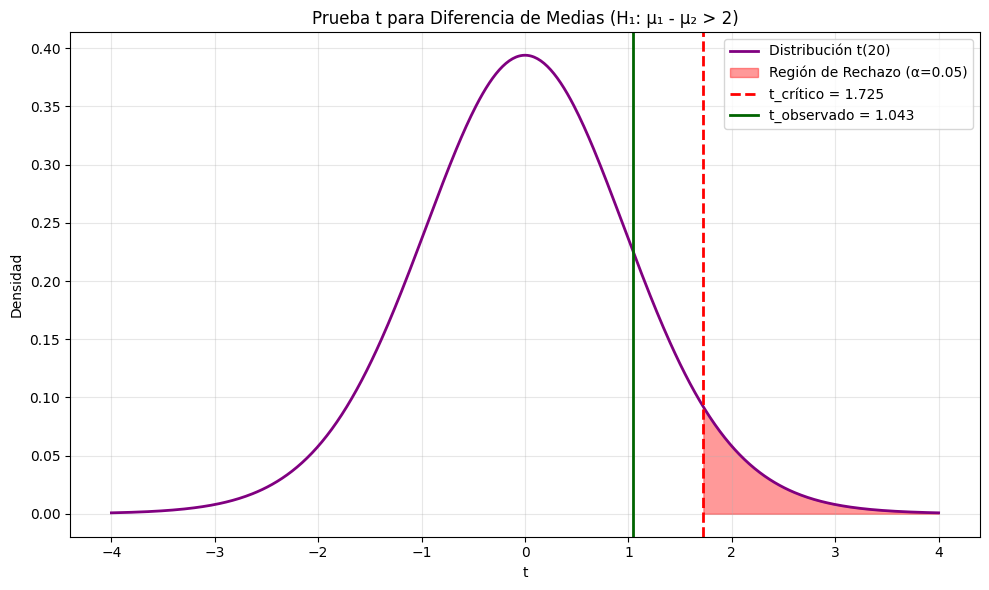

In [ ]:
# ============================================
# @title **C.  EJEMPLO 4: PRUEBA t PARA DIFERENCIA DE MEDIAS**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Datos
n1 = 12
n2 = 10
y1_bar = 85
y2_bar = 81
s1 = 4
s2 = 5
D0 = 2
alpha = 0.05

# Varianza combinada
sp2 = ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# Estadístico de prueba
t_stat = ((y1_bar - y2_bar) - D0) / (sp * np.sqrt(1/n1 + 1/n2))
gl = n1 + n2 - 2
t_critico = t.ppf(1 - alpha, df=gl) # Cola superior
p_valor = 1 - t.cdf(t_stat, df=gl)

print("=== PRUEBA t PARA DIFERENCIA DE MEDIAS ===")
print(f"H₀: μ₁ - μ₂ = 2 vs H₁: μ₁ - μ₂ > 2")
print(f"Varianza combinada Sₚ²: {sp2:.4f}")
print(f"Desviación combinada Sₚ: {sp:.4f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Grados de libertad: {gl}")
print(f"Valor crítico (α=0.05, cola superior): {t_critico:.4f}")
print(f"Valor-p: {p_valor:.4f}\n")

if t_stat > t_critico:
    print("Decisión: Rechazar H₀")
    print("Conclusión: El desgaste del material 1 excede al del material 2 en más de 2 unidades.")
else:
    print("Decisión: No rechazar H₀")
    print("Conclusión: No hay suficiente evidencia para afirmar que el desgaste del material 1 excede al del material 2 en más de 2 unidades.")

# Intervalo de confianza
margen = t_critico * sp * np.sqrt(1/n1 + 1/n2)
ic_inf = (y1_bar - y2_bar) - margen
ic_sup = (y1_bar - y2_bar) + margen

print(f"\nIntervalo de confianza del 95% para μ₁ - μ₂:")
print(f"[{ic_inf:.2f}, {ic_sup:.2f}]")
print("El intervalo contiene el valor 2, lo que respalda no rechazar H₀.")

# ============================================
# VISUALIZACIÓN
# ============================================

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x_vals = np.linspace(-4, 4, 500)
densidad_t = t.pdf(x_vals, df=gl)

ax.plot(x_vals, densidad_t, 'purple', lw=2, label=f'Distribución t({gl})')

# Región de rechazo (cola superior)
x_rechazo = np.linspace(t_critico, 4, 100)
y_rechazo = t.pdf(x_rechazo, df=gl)
ax.fill_between(x_rechazo, y_rechazo, alpha=0.4, color='red', label='Región de Rechazo (α=0.05)')

ax.axvline(t_critico, color='red', linestyle='--', lw=2, label=f't_crítico = {t_critico:.3f}')
ax.axvline(t_stat, color='darkgreen', lw=2, label=f't_observado = {t_stat:.3f}')

ax.set_xlabel('t')
ax.set_ylabel('Densidad')
ax.set_title('Prueba t para Diferencia de Medias (H₁: μ₁ - μ₂ > 2)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio3)

<a name="T28"></a>
## **28. EJEMPLO 5: PRUEBA CHI-CUADRADO PARA UNA VARIANZA**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:

# ============================================
# @title **B. EJEMPLO 5: PRUEBA CHI-CUADRADO PARA UNA VARIANZA**
# ============================================
%%R
# Datos
n <- 10
s <- 1.2
sigma0 <- 0.9
alpha <- 0.05

# Estadístico de prueba
chi2 <- (n - 1) * s^2 / sigma0^2
gl <- n - 1
chi2_critico <- qchisq(1 - alpha, df = gl)
p_valor <- 1 - pchisq(chi2, df = gl)

cat("=== PRUEBA CHI-CUADRADO PARA UNA VARIANZA ===\n")
cat("H₀: σ² = 0.81 vs H₁: σ² > 0.81\n")
cat("Estadístico χ²:", round(chi2, 4), "\n")
cat("Valor crítico (α=0.05):", round(chi2_critico, 4), "\n")
cat("Valor-p:", round(p_valor, 4), "\n\n")

if (chi2 > chi2_critico) {
  cat("Decisión: Rechazar H₀\n")
  cat("Conclusión: La varianza es significativamente mayor que 0.81.\n")
} else {
  cat("Decisión: No rechazar H₀\n")
  cat("Conclusión: No hay suficiente evidencia para afirmar que la varianza es mayor que 0.81.\n")
}

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN CHI-CUADRADO
# ============================================

x_vals <- seq(0, 30, length.out = 500)
densidad <- dchisq(x_vals, df = gl)

plot(x_vals, densidad, type = "l", lwd = 2, col = "purple",
     xlab = expression(chi^2), ylab = "Densidad",
     main = paste("Distribución χ² con", gl, "grados de libertad"))

# Región de rechazo (cola superior)
x_rechazo <- seq(chi2_critico, 30, length.out = 100)
y_rechazo <- dchisq(x_rechazo, df = gl)
polygon(c(x_rechazo, rev(x_rechazo)), c(y_rechazo, rep(0, length(x_rechazo))),
        col = rgb(0.8, 0.2, 0.2, 0.4), border = NA)

abline(v = chi2_critico, col = "red", lty = 2, lwd = 2)
abline(v = chi2, col = "darkgreen", lwd = 2)

legend("topright",
       legend = c("Región de rechazo (α=0.05)", paste("χ²_obs =", round(chi2, 3))),
       fill = c(rgb(0.8, 0.2, 0.2, 0.4), NA),
       col = c(NA, "darkgreen"), lty = c(NA, 1), lwd = c(NA, 2), bty = "n")





In [ ]:
# ============================================
# @title **C. EJEMPLO 5: PRUEBA CHI-CUADRADO PARA UNA VARIANZA**
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Datos
n = 10
s = 1.2
sigma0 = 0.9
alpha = 0.05

# Estadístico de prueba
chi2_stat = (n - 1) * s**2 / sigma0**2
gl = n - 1
chi2_critico = chi2.ppf(1 - alpha, df=gl)
p_valor = 1 - chi2.cdf(chi2_stat, df=gl)

print("=== PRUEBA CHI-CUADRADO PARA UNA VARIANZA ===")
print(f"H₀: σ² = 0.81 vs H₁: σ² > 0.81")
print(f"Estadístico χ²: {chi2_stat:.4f}")
print(f"Valor crítico (α=0.05): {chi2_critico:.4f}")
print(f"Valor-p: {p_valor:.4f}\n")

if chi2_stat > chi2_critico:
    print("Decisión: Rechazar H₀")
    print("Conclusión: La varianza es significativamente mayor que 0.81.")
else:
    print("Decisión: No rechazar H₀")
    print("Conclusión: No hay suficiente evidencia para afirmar que la varianza es mayor que 0.81.")

# ============================================
# VISUALIZACIÓN
# ============================================

x_vals = np.linspace(0, 30, 500)
densidad = chi2.pdf(x_vals, df=gl)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, densidad, 'purple', lw=2, label=f'χ²({gl})')

x_rechazo = np.linspace(chi2_critico, 30, 100)
y_rechazo = chi2.pdf(x_rechazo, df=gl)
ax.fill_between(x_rechazo, y_rechazo, alpha=0.4, color='red')
ax.axvline(chi2_critico, color='red', linestyle='--', lw=2,
           label=f'χ²_crítico = {chi2_critico:.3f}')
ax.axvline(chi2_stat, color='darkgreen', lw=2,
           label=f'χ²_obs = {chi2_stat:.3f}')
ax.set_xlabel(r'$\chi^2$')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución χ² con {gl} grados de libertad')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio3)